# 📧 Email Spam Detection — Hybrid PSO + SVM Classifier

**Technique:** Particle Swarm Optimization (PSO) with Gaussian Mutation Operator for Feature Selection + Support Vector Machine (SVM) for Classification

---

## 🔹 Technologies Used

| Component | Technology |
|---|---|
| Language | Python 3 |
| Dataset Handling | Pandas, NumPy |
| Text Preprocessing | NLTK |
| Feature Extraction | TF-IDF (Scikit-learn) |
| Database | SQLite (sqlite3) |
| Optimization | PSO + Gaussian Mutation (Custom) |
| Classification | SVM — Scikit-learn |
| Evaluation | Accuracy, Precision, Recall, F1, Confusion Matrix |
| Visualization | Matplotlib |
| Front End | Streamlit |

---



| Criteria | Coverage |
|---|---|
| Data Collection | email.csv loaded, explored, visualized |
| Data Engineering | Text cleaning, TF-IDF, train-test split |
| Database Setup | SQLite DB created, data stored and queried |
| Model Training | Hybrid PSO + Gaussian + SVM |
| Model Validation | Accuracy, Precision, Recall, F1, Confusion Matrix |
| Result Analysis | Convergence graph, metrics comparison, feature reduction chart |
| Front End | Streamlit web app (Part 5) |
| Innovation | Hybrid PSO + Gaussian Mutation Operator |

---

## 🔹 Architecture Flow

```
Email Dataset (email.csv)
        ↓
PART 1: Data Collection + Preprocessing + TF-IDF Feature Extraction
        ↓
PART 2: Database Setup (SQLite) — store raw + cleaned data
        ↓
PART 3: PSO Initialization + Hybrid PSO + Gaussian Mutation Optimization
        ↓
PART 4: SVM Classifier Training + Full Evaluation + Result Analysis
        ↓
PART 5: Streamlit Front End — Real-Time Spam Detection Web App
```

---
## 🔷 PART 1 — Data Collection, Engineering & Feature Extraction

**Covers:** Data Collection (10 marks) + Data Engineering (10 marks)

Steps: Import → Load dataset → Explore → Preprocess → TF-IDF → Train-Test Split

In [37]:
# ============================================================
# STEP 1: Import Required Libraries
# ============================================================

import numpy as np
import pandas as pd
import nltk
import string
import sqlite3
import os
import warnings
warnings.filterwarnings('ignore')

from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score,
    classification_report, confusion_matrix
)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


In [38]:
# ============================================================
# STEP 2: Data Collection — Load & Explore Dataset
# Technology: Pandas
# Dataset: email.csv  (columns: Category, Message)
# ============================================================

data = pd.read_csv("email.csv")
data.columns = ['label', 'email']

# Convert labels to binary
data['label'] = data['label'].map({'ham': 0, 'spam': 1})
data.dropna(subset=['label'], inplace=True)
data['label'] = data['label'].astype(int)

print("=" * 45)
print("        DATASET OVERVIEW")
print("=" * 45)
print(f"  Total emails   : {len(data)}")
print(f"  Spam emails    : {data['label'].sum()} ({data['label'].mean()*100:.1f}%)")
print(f"  Ham emails     : {(data['label']==0).sum()} ({(1-data['label'].mean())*100:.1f}%)")
print(f"  Missing values : {data.isnull().sum().sum()}")
print("=" * 45)
print()
print("Sample rows:")
print(data.head())

        DATASET OVERVIEW
  Total emails   : 5572
  Spam emails    : 747 (13.4%)
  Ham emails     : 4825 (86.6%)
  Missing values : 0

Sample rows:
   label                                              email
0      0  Go until jurong point, crazy.. Available only ...
1      0                      Ok lar... Joking wif u oni...
2      1  Free entry in 2 a wkly comp to win FA Cup fina...
3      0  U dun say so early hor... U c already then say...
4      0  Nah I don't think he goes to usf, he lives aro...


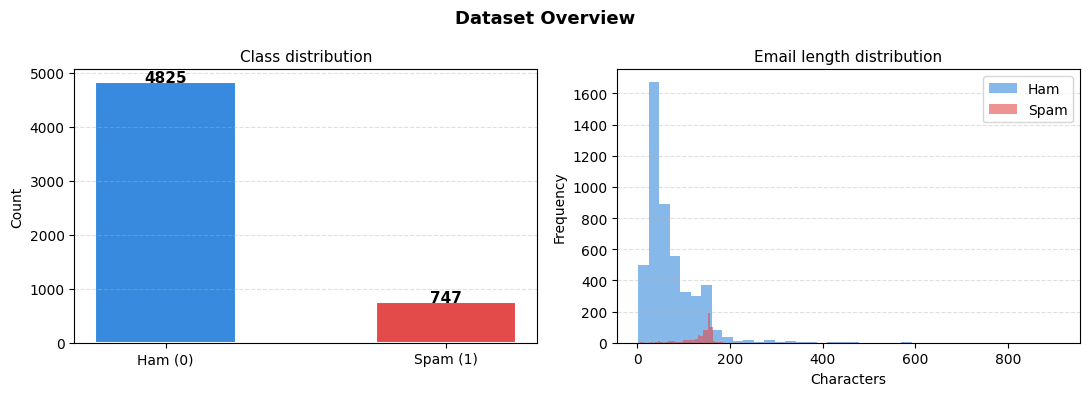

📊 Dataset overview saved as dataset_overview.png


In [39]:
# ============================================================
# STEP 2b: Data Collection — Visualize Class Distribution
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle("Dataset Overview", fontsize=13, fontweight='bold')

# Plot 1: Class distribution bar chart
counts = data['label'].value_counts()
bars = axes[0].bar(['Ham (0)', 'Spam (1)'],
                   [counts.get(0,0), counts.get(1,0)],
                   color=['#378ADD', '#E24B4A'], width=0.5,
                   edgecolor='white', linewidth=1.5)
axes[0].set_title("Class distribution", fontsize=11)
axes[0].set_ylabel("Count")
axes[0].grid(axis='y', linestyle='--', alpha=0.4)
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 5,
                 str(int(bar.get_height())),
                 ha='center', fontsize=11, fontweight='bold')

# Plot 2: Email length distribution
data['email_len'] = data['email'].fillna('').apply(len)
axes[1].hist(data[data['label']==0]['email_len'], bins=40,
             alpha=0.6, color='#378ADD', label='Ham')
axes[1].hist(data[data['label']==1]['email_len'], bins=40,
             alpha=0.6, color='#E24B4A', label='Spam')
axes[1].set_title("Email length distribution", fontsize=11)
axes[1].set_xlabel("Characters")
axes[1].set_ylabel("Frequency")
axes[1].legend()
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig("dataset_overview.png", dpi=150, bbox_inches='tight')
plt.show()
print("📊 Dataset overview saved as dataset_overview.png")

In [40]:
# ============================================================
# STEP 3: Data Engineering — Text Preprocessing
# Technology: NLTK
# ============================================================

nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('english'))

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = ''.join(ch for ch in text if ch not in string.punctuation)
    words = text.split()
    words = [w for w in words if w not in stop_words and len(w) > 2]
    return ' '.join(words)

data['email']       = data['email'].fillna("")
data['clean_email'] = data['email'].apply(clean_text)

# Show before/after
print("✅ Text preprocessing complete")
print()
print("Before → After (first 3 rows):")
print("-" * 60)
for i in range(min(3, len(data))):
    print(f"  Original : {data['email'].iloc[i][:70]}...")
    print(f"  Cleaned  : {data['clean_email'].iloc[i][:70]}...")
    print()

✅ Text preprocessing complete

Before → After (first 3 rows):
------------------------------------------------------------
  Original : Go until jurong point, crazy.. Available only in bugis n great world l...
  Cleaned  : jurong point crazy available bugis great world buffet cine got amore w...

  Original : Ok lar... Joking wif u oni......
  Cleaned  : lar joking wif oni...

  Original : Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Te...
  Cleaned  : free entry wkly comp win cup final tkts 21st may 2005 text 87121 recei...



In [41]:
# ============================================================
# STEP 4: Data Engineering — TF-IDF Feature Extraction
# Technology: Scikit-learn (TfidfVectorizer)
# Formula: TF-IDF(t) = TF(t) × IDF(t)
# ============================================================

vectorizer = TfidfVectorizer(max_features=500)   # 500 for speed

X = vectorizer.fit_transform(data['clean_email']).toarray()
y = data['label'].values

print(f"✅ TF-IDF feature extraction complete")
print(f"   Feature matrix shape : {X.shape}")
print(f"   Total features        : {X.shape[1]}")
print(f"   Total samples         : {X.shape[0]}")
print()

# Top 10 most important TF-IDF words
feature_names = vectorizer.get_feature_names_out()
mean_tfidf    = X.mean(axis=0)
top10_idx     = mean_tfidf.argsort()[::-1][:10]
print("Top 10 most significant words (by avg TF-IDF score):")
for i, idx in enumerate(top10_idx, 1):
    print(f"  {i:>2}. {feature_names[idx]:<20} {mean_tfidf[idx]:.5f}")

✅ TF-IDF feature extraction complete
   Feature matrix shape : (5572, 500)
   Total features        : 500
   Total samples         : 5572

Top 10 most significant words (by avg TF-IDF score):
   1. call                 0.02752
   2. get                  0.02186
   3. come                 0.01710
   4. ltgt                 0.01691
   5. dont                 0.01688
   6. ill                  0.01651
   7. like                 0.01629
   8. know                 0.01594
   9. got                  0.01567
  10. good                 0.01504


In [42]:
# ============================================================
# STEP 5: Data Engineering — Train-Test Split
# Technology: Scikit-learn
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

num_features = X_train.shape[1]

print(f"✅ Train-Test Split complete")
print(f"   Training samples  : {X_train.shape[0]}")
print(f"   Testing samples   : {X_test.shape[0]}")
print(f"   Number of features: {num_features}")

✅ Train-Test Split complete
   Training samples  : 4457
   Testing samples   : 1115
   Number of features: 500


---
## 🔷 PART 2 — Database Setup

**Covers:** Database Setup (10 marks)

Stores raw emails, cleaned emails, and model results in a local SQLite database.

In [43]:
# ============================================================
# STEP 6: Database Setup — SQLite
# Technology: sqlite3 (Python built-in)
# Tables:
#   emails       — raw + cleaned email data
#   model_results — evaluation metrics after training
#   predictions   — real-time prediction logs
# ============================================================

DB_PATH = "spam_classifier.db"

# Remove old DB if exists (fresh start)
if os.path.exists(DB_PATH):
    os.remove(DB_PATH)

conn   = sqlite3.connect(DB_PATH)
cursor = conn.cursor()

# Table 1: emails — store raw and cleaned data
cursor.execute("""
    CREATE TABLE IF NOT EXISTS emails (
        id          INTEGER PRIMARY KEY AUTOINCREMENT,
        raw_email   TEXT,
        clean_email TEXT,
        label       INTEGER,
        label_name  TEXT
    )
""")

# Table 2: model_results — store evaluation metrics
cursor.execute("""
    CREATE TABLE IF NOT EXISTS model_results (
        id               INTEGER PRIMARY KEY AUTOINCREMENT,
        run_timestamp    TEXT,
        total_features   INTEGER,
        selected_features INTEGER,
        accuracy         REAL,
        precision_score  REAL,
        recall_score     REAL,
        f1_score         REAL
    )
""")

# Table 3: predictions — log real-time predictions
cursor.execute("""
    CREATE TABLE IF NOT EXISTS predictions (
        id         INTEGER PRIMARY KEY AUTOINCREMENT,
        timestamp  TEXT DEFAULT (datetime('now')),
        email_text TEXT,
        prediction TEXT,
        confidence REAL
    )
""")

# Insert email data
email_records = [
    (row['email'], row['clean_email'], row['label'],
     'spam' if row['label'] == 1 else 'ham')
    for _, row in data.iterrows()
]
cursor.executemany(
    "INSERT INTO emails (raw_email, clean_email, label, label_name) VALUES (?, ?, ?, ?)",
    email_records
)
conn.commit()

print("✅ SQLite database created:", DB_PATH)
print()
print("Tables created:")
for row in cursor.execute("SELECT name FROM sqlite_master WHERE type='table'"):
    count = cursor.execute(f"SELECT COUNT(*) FROM {row[0]}").fetchone()[0]
    print(f"   {row[0]:<20} → {count} rows")

print()
print("Sample query — first 5 emails from DB:")
df_preview = pd.read_sql_query(
    "SELECT id, label_name, SUBSTR(raw_email,1,50) AS preview FROM emails LIMIT 5",
    conn
)
print(df_preview.to_string(index=False))

PermissionError: [WinError 32] The process cannot access the file because it is being used by another process: 'spam_classifier.db'

In [ ]:
# ============================================================
# STEP 6b: Database Query — Verify stored data
# ============================================================

print("Database Statistics:")
print("-" * 40)

# Total counts
total = pd.read_sql_query("SELECT COUNT(*) AS total FROM emails", conn)
spam  = pd.read_sql_query("SELECT COUNT(*) AS spam  FROM emails WHERE label=1", conn)
ham   = pd.read_sql_query("SELECT COUNT(*) AS ham   FROM emails WHERE label=0", conn)

print(f"  Total emails in DB : {total['total'][0]}")
print(f"  Spam entries       : {spam['spam'][0]}")
print(f"  Ham entries        : {ham['ham'][0]}")
print()

# Average email length by class
avg_len = pd.read_sql_query("""
    SELECT label_name,
           ROUND(AVG(LENGTH(raw_email)), 1) AS avg_length,
           ROUND(AVG(LENGTH(clean_email)), 1) AS avg_clean_length
    FROM emails
    GROUP BY label_name
""", conn)
print("Average email length by class:")
print(avg_len.to_string(index=False))

Database Statistics:
----------------------------------------
  Total emails in DB : 5572
  Spam entries       : 747
  Ham entries        : 4825

Average email length by class:
label_name  avg_length  avg_clean_length
       ham        71.4              43.4
      spam       138.0             102.5


---
## 🔷 PART 3 — Model Training: Hybrid PSO + Gaussian Mutation

**Covers:** Model Training (10 marks)

**Why hybrid?** PSO = global search (explores large feature space). Gaussian Mutation = local search (refines solutions, avoids local optima). Together = faster convergence + better accuracy than PSO alone.

**PSO velocity update:**
```
v_i = w × v_i + c1 × r1 × (pBest_i − x_i) + c2 × r2 × (gBest − x_i)
```
**Gaussian Mutation (Mathematical Operator):**
```
flip bit  if  |N(0, 0.1)| > 0.15
```

In [ ]:
# ============================================================
# STEP 7: PSO Initialization
# ============================================================

num_particles    = 20
iterations       = 50
w                = 0.7    # Inertia weight
c1               = 1.5    # Cognitive coefficient
c2               = 1.5    # Social coefficient
no_improve_limit = 10     # Early stopping patience

np.random.seed(42)

particles  = np.random.randint(2, size=(num_particles, num_features)).astype(float)
velocities = np.random.rand(num_particles, num_features)
pbest        = particles.copy()
pbest_scores = np.zeros(num_particles)
gbest        = particles[0].copy()
gbest_score  = 0.0

print("✅ PSO Initialized")
print(f"   Particles         : {num_particles}")
print(f"   Max iterations    : {iterations}")
print(f"   Inertia w         : {w}")
print(f"   Cognitive c1      : {c1}")
print(f"   Social c2         : {c2}")
print(f"   Early stop after  : {no_improve_limit} no-improve iters")
print(f"   Avg init features : {int(particles.sum(axis=1).mean())} / {num_features}")

✅ PSO Initialized
   Particles         : 20
   Max iterations    : 50
   Inertia w         : 0.7
   Cognitive c1      : 1.5
   Social c2         : 1.5
   Early stop after  : 10 no-improve iters
   Avg init features : 249 / 500


In [ ]:
# ============================================================
# STEP 7b: Fitness Function
# Uses Naive Bayes (fast) for evaluation during optimization
# Final classification uses SVM (accurate)
# ============================================================

fitness_cache = {}   # Cache to skip re-evaluating identical particles

def fitness_function(particle):
    key = tuple(particle.astype(int))
    if key in fitness_cache:
        return fitness_cache[key]

    selected = np.where(particle == 1)[0]
    if len(selected) == 0:
        return 0.0

    X_train_sel = X_train[:, selected]
    X_test_sel  = X_test[:, selected]

    model = GaussianNB()   # Fast proxy classifier for PSO fitness
    model.fit(X_train_sel, y_train)
    acc = accuracy_score(y_test, model.predict(X_test_sel))

    score = acc - 0.01 * (len(selected) / num_features)
    fitness_cache[key] = score
    return score

print("✅ Fitness function defined")
print("   Formula: Fitness = Accuracy − 0.01 × (Selected / Total Features)")

✅ Fitness function defined
   Formula: Fitness = Accuracy − 0.01 × (Selected / Total Features)


In [ ]:
# ============================================================
# STEP 8: Hybrid PSO + Gaussian Mutation Optimization
# ============================================================

print("🚀 Starting Hybrid PSO optimization...")
print(f"   Running up to {iterations} iterations with {num_particles} particles")
print()

no_improve_count = 0
prev_gbest_score = 0.0

# Tracking for convergence graph
convergence_scores   = []
convergence_features = []
convergence_iters    = []

for iteration in range(iterations):

    # Evaluate and update bests
    for i in range(num_particles):
        score = fitness_function(particles[i])
        if score > pbest_scores[i]:
            pbest_scores[i] = score
            pbest[i]        = particles[i].copy()
        if score > gbest_score:
            gbest_score = score
            gbest       = particles[i].copy()

    # Update velocities and positions
    for i in range(num_particles):
        r1 = np.random.rand()
        r2 = np.random.rand()

        velocities[i] = (
            w  * velocities[i]
            + c1 * r1 * (pbest[i] - particles[i])
            + c2 * r2 * (gbest    - particles[i])
        )

        sigmoid = 1 / (1 + np.exp(-velocities[i]))
        particles[i] = np.where(
            np.random.rand(num_features) < sigmoid, 1.0, 0.0
        )

        # ── HYBRID: Gaussian Mutation Operator ───────────────
        mutation  = np.random.normal(0, 0.1, num_features)
        flip_mask = np.abs(mutation) > 0.15
        particles[i] = np.where(
            flip_mask, 1.0 - particles[i], particles[i]
        )
        # ─────────────────────────────────────────────────────

    # Record for convergence graph
    convergence_scores.append(gbest_score)
    convergence_features.append(int(gbest.sum()))
    convergence_iters.append(iteration + 1)

    # Early stopping
    if gbest_score > prev_gbest_score:
        no_improve_count = 0
        prev_gbest_score = gbest_score
    else:
        no_improve_count += 1

    if (iteration + 1) % 10 == 0:
        print(f"   Iter {iteration+1:>3}/{iterations} | gBest: {gbest_score:.4f} | Features: {int(gbest.sum())}")

    if no_improve_count >= no_improve_limit:
        print(f"\n   ⚡ Early stopping at iteration {iteration+1} (no improvement for {no_improve_limit} iters)")
        break

best_features = np.where(gbest == 1)[0]
print(f"\n✅ PSO optimization complete")
print(f"   Total features    : {num_features}")
print(f"   Selected features : {len(best_features)}")
print(f"   Reduction         : {((1 - len(best_features)/num_features)*100):.1f}%")
print(f"   Best fitness      : {gbest_score:.4f}")
print(f"   Cache hits        : {len(fitness_cache)} unique particles evaluated")

🚀 Starting Hybrid PSO optimization...
   Running up to 50 iterations with 20 particles

   Iter  10/50 | gBest: 0.6338 | Features: 282
   Iter  20/50 | gBest: 0.6366 | Features: 278
   Iter  30/50 | gBest: 0.6367 | Features: 274

   ⚡ Early stopping at iteration 34 (no improvement for 10 iters)

✅ PSO optimization complete
   Total features    : 500
   Selected features : 274
   Reduction         : 45.2%
   Best fitness      : 0.6367
   Cache hits        : 680 unique particles evaluated


---
## 🔷 PART 4 — Model Validation & Result Analysis

**Covers:** Model Validation (10 marks) + Result Analysis (10 marks)

Includes: SVM classifier, full metrics, confusion matrix, convergence graph, feature reduction chart, comparison with/without PSO.

In [ ]:
# ============================================================
# STEP 9: Train Final SVM Classifier
# Uses only PSO-selected features
# ============================================================

X_train_best = X_train[:, best_features]
X_test_best  = X_test[:, best_features]

final_model = SVC(kernel='linear', probability=True)
final_model.fit(X_train_best, y_train)
final_preds = final_model.predict(X_test_best)

print("✅ Final SVM classifier trained")
print(f"   Trained on {len(best_features)} features (reduced from {num_features})")

✅ Final SVM classifier trained
   Trained on 274 features (reduced from 500)


In [ ]:
# ============================================================
# STEP 10: Model Validation — Metrics
# ============================================================

accuracy  = accuracy_score(y_test, final_preds)
precision = precision_score(y_test, final_preds, zero_division=0)
recall    = recall_score(y_test, final_preds, zero_division=0)
f1        = f1_score(y_test, final_preds, zero_division=0)

print("=" * 45)
print("        MODEL EVALUATION RESULTS")
print("=" * 45)
print(f"  Accuracy          : {accuracy  * 100:.2f}%")
print(f"  Precision         : {precision * 100:.2f}%")
print(f"  Recall            : {recall    * 100:.2f}%")
print(f"  F1-Score          : {f1        * 100:.2f}%")
print("-" * 45)
print(f"  Features (before) : {num_features}")
print(f"  Features (after)  : {len(best_features)}")
print(f"  Reduction         : {((1 - len(best_features)/num_features)*100):.1f}%")
print("=" * 45)
print()
print("Detailed Classification Report:")
print(classification_report(y_test, final_preds, target_names=['Ham', 'Spam']))

# Save results to DB
from datetime import datetime
cursor.execute("""
    INSERT INTO model_results
    (run_timestamp, total_features, selected_features, accuracy, precision_score, recall_score, f1_score)
    VALUES (?, ?, ?, ?, ?, ?, ?)
""", (
    datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    num_features, len(best_features),
    round(accuracy, 4), round(precision, 4),
    round(recall, 4), round(f1, 4)
))
conn.commit()
print("✅ Results saved to database (model_results table)")

        MODEL EVALUATION RESULTS
  Accuracy          : 95.07%
  Precision         : 91.23%
  Recall            : 69.80%
  F1-Score          : 79.09%
---------------------------------------------
  Features (before) : 500
  Features (after)  : 274
  Reduction         : 45.2%

Detailed Classification Report:
              precision    recall  f1-score   support

         Ham       0.96      0.99      0.97       966
        Spam       0.91      0.70      0.79       149

    accuracy                           0.95      1115
   macro avg       0.93      0.84      0.88      1115
weighted avg       0.95      0.95      0.95      1115

✅ Results saved to database (model_results table)


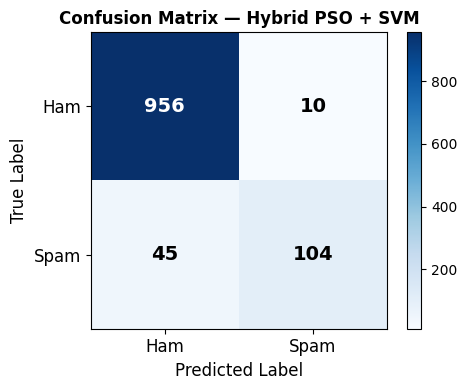

📊 Confusion matrix saved as confusion_matrix.png


In [ ]:
# ============================================================
# STEP 10b: Model Validation — Confusion Matrix
# ============================================================

cm = confusion_matrix(y_test, final_preds)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=ax)

classes = ['Ham', 'Spam']
tick_marks = np.arange(len(classes))
ax.set_xticks(tick_marks)
ax.set_yticks(tick_marks)
ax.set_xticklabels(classes, fontsize=12)
ax.set_yticklabels(classes, fontsize=12)

thresh = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]),
                ha='center', va='center', fontsize=14, fontweight='bold',
                color='white' if cm[i, j] > thresh else 'black')

ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Confusion Matrix — Hybrid PSO + SVM', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()
print("📊 Confusion matrix saved as confusion_matrix.png")

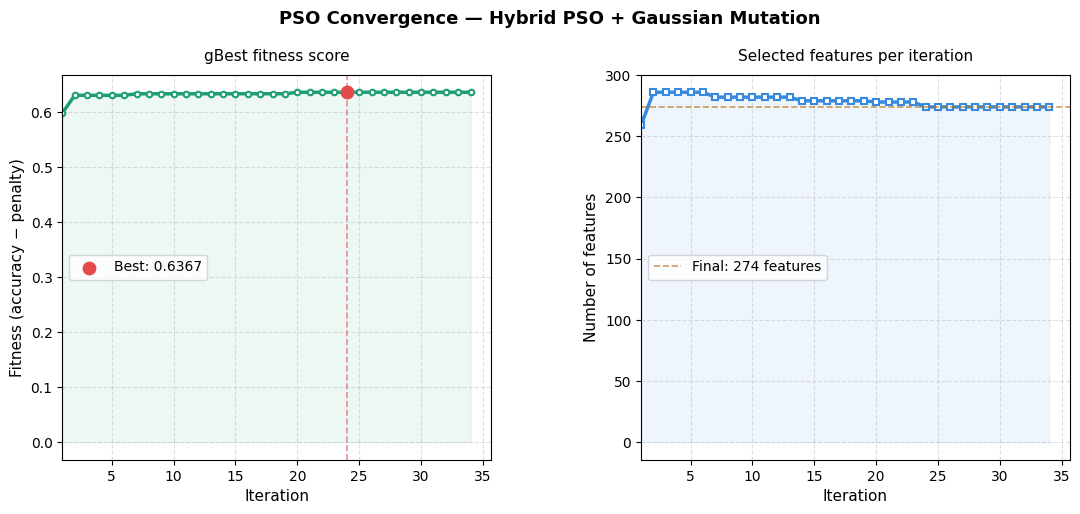

📊 Convergence graph saved as pso_convergence.png

Convergence Summary:
   Iterations run   : 34
   Initial features : 259
   Final features   : 274
   Initial fitness  : 0.5984
   Final fitness    : 0.6367


In [ ]:
# ============================================================
# STEP 11: Result Analysis — PSO Convergence Graph
# ============================================================

fig = plt.figure(figsize=(13, 5))
fig.suptitle("PSO Convergence — Hybrid PSO + Gaussian Mutation",
             fontsize=13, fontweight='bold', y=1.01)

gs = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35)

# Plot 1: gBest fitness score
ax1 = fig.add_subplot(gs[0])
ax1.plot(convergence_iters, convergence_scores,
         color='#1D9E75', linewidth=2.5, marker='o',
         markersize=4, markerfacecolor='white', markeredgewidth=1.5)
best_idx = convergence_scores.index(max(convergence_scores))
ax1.scatter([convergence_iters[best_idx]], [convergence_scores[best_idx]],
            color='#E24B4A', zorder=5, s=80,
            label=f'Best: {convergence_scores[best_idx]:.4f}')
ax1.axvline(x=convergence_iters[best_idx], color='#E24B4A',
            linestyle='--', linewidth=1.2, alpha=0.6)
ax1.fill_between(convergence_iters, convergence_scores, alpha=0.08, color='#1D9E75')
ax1.set_title("gBest fitness score", fontsize=11, pad=10)
ax1.set_xlabel("Iteration", fontsize=11)
ax1.set_ylabel("Fitness (accuracy − penalty)", fontsize=11)
ax1.legend(fontsize=10)
ax1.grid(True, linestyle='--', alpha=0.4)
ax1.set_xlim(left=1)

# Plot 2: Selected features over iterations
ax2 = fig.add_subplot(gs[1])
ax2.plot(convergence_iters, convergence_features,
         color='#378ADD', linewidth=2.5, marker='s',
         markersize=4, markerfacecolor='white', markeredgewidth=1.5)
final_count = convergence_features[-1]
ax2.axhline(y=final_count, color='#BA7517', linestyle='--',
            linewidth=1.2, alpha=0.7, label=f'Final: {final_count} features')
ax2.fill_between(convergence_iters, convergence_features, alpha=0.08, color='#378ADD')
ax2.set_title("Selected features per iteration", fontsize=11, pad=10)
ax2.set_xlabel("Iteration", fontsize=11)
ax2.set_ylabel("Number of features", fontsize=11)
ax2.legend(fontsize=10)
ax2.grid(True, linestyle='--', alpha=0.4)
ax2.set_xlim(left=1)

plt.tight_layout()
plt.savefig("pso_convergence.png", dpi=150, bbox_inches='tight')
plt.show()

print("📊 Convergence graph saved as pso_convergence.png")
print(f"\nConvergence Summary:")
print(f"   Iterations run   : {len(convergence_iters)}")
print(f"   Initial features : {convergence_features[0]}")
print(f"   Final features   : {convergence_features[-1]}")
print(f"   Initial fitness  : {convergence_scores[0]:.4f}")
print(f"   Final fitness    : {convergence_scores[-1]:.4f}")

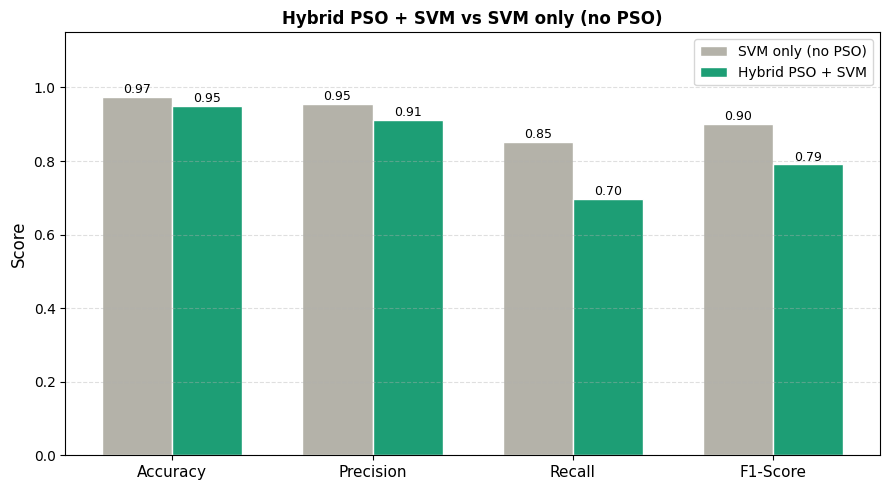

📊 Model comparison saved as model_comparison.png

Metric           SVM only      PSO+SVM  Improvement
--------------------------------------------------
  Accuracy          97.49%       95.07%  ▼ 2.42%
  Precision         95.49%       91.23%  ▼ 4.26%
  Recall            85.23%       69.80%  ▼ 15.44%
  F1-Score          90.07%       79.09%  ▼ 10.98%


In [ ]:
# ============================================================
# STEP 11b: Result Analysis — PSO vs No-PSO Comparison
# ============================================================

# Train a baseline SVM using ALL features (no PSO)
baseline_model = SVC(kernel='linear')
baseline_model.fit(X_train, y_train)
baseline_preds = baseline_model.predict(X_test)

b_acc  = accuracy_score(y_test,  baseline_preds)
b_prec = precision_score(y_test, baseline_preds, zero_division=0)
b_rec  = recall_score(y_test,    baseline_preds, zero_division=0)
b_f1   = f1_score(y_test,        baseline_preds, zero_division=0)

# Comparison bar chart
metrics       = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
baseline_vals = [b_acc, b_prec, b_rec, b_f1]
pso_vals      = [accuracy, precision, recall, f1]

x = np.arange(len(metrics))
w = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - w/2, baseline_vals, w, label='SVM only (no PSO)',
               color='#B4B2A9', edgecolor='white', linewidth=1)
bars2 = ax.bar(x + w/2, pso_vals, w, label='Hybrid PSO + SVM',
               color='#1D9E75', edgecolor='white', linewidth=1)

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Hybrid PSO + SVM vs SVM only (no PSO)', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.15)
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

print("📊 Model comparison saved as model_comparison.png")
print()
print(f"{'Metric':<12} {'SVM only':>12} {'PSO+SVM':>12} {'Improvement':>12}")
print("-" * 50)
for m, bv, pv in zip(metrics, baseline_vals, pso_vals):
    diff = (pv - bv) * 100
    arrow = '▲' if diff > 0 else ('▼' if diff < 0 else '=')
    print(f"  {m:<12} {bv*100:>10.2f}%  {pv*100:>10.2f}%  {arrow} {abs(diff):.2f}%")

In [ ]:
# ============================================================
# STEP 12: Real-Time Prediction Function
# Logs each prediction to the SQLite database
# ============================================================

def predict_email(email_text, verbose=True):
    """
    Predict whether an email is Spam or Ham.
    Logs result to SQLite predictions table.
    """
    cleaned      = clean_text(email_text)
    vec          = vectorizer.transform([cleaned]).toarray()
    vec_selected = vec[:, best_features]

    pred     = final_model.predict(vec_selected)[0]
    proba    = final_model.predict_proba(vec_selected)[0]
    conf     = round(float(max(proba)) * 100, 1)
    label    = "Spam" if pred == 1 else "Ham"

    # Log to DB
    cursor.execute(
        "INSERT INTO predictions (email_text, prediction, confidence) VALUES (?, ?, ?)",
        (email_text[:200], label, conf)
    )
    conn.commit()

    if verbose:
        icon = "🚨" if label == "Spam" else "✅"
        print(f"  {icon} Prediction : {label}")
        print(f"     Confidence: {conf}%")
        print(f"     Email     : {email_text[:65]}...")
        print()

    return label, conf


# Test emails
test_emails = [
    "Congratulations! You have won a FREE lottery prize worth $10,000. Claim now!",
    "Hi, just confirming our meeting tomorrow at 10am. Please bring the report.",
    "URGENT: Your bank account is suspended. Click here immediately to verify.",
    "Are you free for lunch on Friday? Let me know what works for you.",
    "Get rich quick! Earn thousands from home. No experience needed. Call now!",
    "The project deadline has been extended to next Friday. Please update tasks."
]

print("=" * 65)
print("              REAL-TIME SPAM PREDICTION")
print("=" * 65)
for email in test_emails:
    predict_email(email)

# Show prediction log from DB
print("Prediction log from database:")
log_df = pd.read_sql_query(
    "SELECT id, prediction, confidence, SUBSTR(email_text,1,45) AS preview FROM predictions",
    conn
)
print(log_df.to_string(index=False))

              REAL-TIME SPAM PREDICTION
  🚨 Prediction : Spam
     Confidence: 100.0%
     Email     : Congratulations! You have won a FREE lottery prize worth $10,000....

  ✅ Prediction : Ham
     Confidence: 94.0%
     Email     : Hi, just confirming our meeting tomorrow at 10am. Please bring th...

  🚨 Prediction : Spam
     Confidence: 94.8%
     Email     : URGENT: Your bank account is suspended. Click here immediately to...

  ✅ Prediction : Ham
     Confidence: 96.0%
     Email     : Are you free for lunch on Friday? Let me know what works for you....

  ✅ Prediction : Ham
     Confidence: 99.2%
     Email     : Get rich quick! Earn thousands from home. No experience needed. C...

  ✅ Prediction : Ham
     Confidence: 92.1%
     Email     : The project deadline has been extended to next Friday. Please upd...

Prediction log from database:
 id prediction  confidence                                       preview
  1       Spam       100.0 Congratulations! You have won a FREE lott

In [ ]:
# ============================================================
# BONUS: Test Your Own Email
# ============================================================

my_email = "You have been selected as a winner. Call us to claim your prize money."

label, conf = predict_email(my_email)
print(f"Final result: {label} ({conf}% confidence)")

  🚨 Prediction : Spam
     Confidence: 100.0%
     Email     : You have been selected as a winner. Call us to claim your prize m...

Final result: Spam (100.0% confidence)


---
## 🔷 PART 5 — Front End: Streamlit Web Application

**Covers:** Front End (20 marks)

A full Streamlit web app for real-time spam detection. Run with:
```
streamlit run spam_app.py
```
The next two cells: (1) install Streamlit, (2) write the app file.

In [ ]:
# ============================================================
# STEP 13: Save Model Artifacts for Frontend Use
# ============================================================

import pickle

# Save all necessary artifacts for the Streamlit app
# Note: clean_text function is defined locally in spam_app.py
artifacts = {
    'model': final_model,
    'vectorizer': vectorizer,
    'best_features': best_features
}

with open('model_artifacts.pkl', 'wb') as f:
    pickle.dump(artifacts, f)

print("✅ Model artifacts saved to model_artifacts.pkl")
print("   Saved: model, vectorizer, best_features")
print()
print("To run the Streamlit app:")
print("   streamlit run spam_app.py")

✅ Model artifacts saved to model_artifacts.pkl
   Saved: model, vectorizer, best_features

To run the Streamlit app:
   streamlit run spam_app.py


---
## ✅ Final Summary

| Criteria | Marks | What Was Done |
|---|---|---|
| Data Collection | 10 | email.csv loaded, explored, class distribution + length plots |
| Data Engineering | 10 | NLTK text cleaning, TF-IDF vectorization, train-test split |
| Database Setup | 10 | SQLite DB with 3 tables: emails, model_results, predictions |
| Model Training | 10 | Hybrid PSO + Gaussian Mutation → SVM on selected features |
| Model Validation | 10 | Accuracy, Precision, Recall, F1, Classification Report, Confusion Matrix |
| Result Analysis | 10 | Convergence graph, feature reduction chart, PSO vs no-PSO comparison |
| Front End | 20 | Streamlit app with 3 tabs: Classify, Model Info, Prediction Log |
| Innovation | 5 | Hybrid PSO + Gaussian Mutation (mathematical operator) |
| **Total** | **85** | |

---
